# Detect the anomaly in hydro generation in 2022 Yangtze River Basin

[DEBUG] sichuan    | hydro Jun= 426.4000 | hydro Sep= 333.0000 | diff(Sep-Jun)=-93.4000 | std_anomaly Jun= 2.6515 | Sep=-1.8289
[DEBUG] chongqing  | hydro Jun= 28.0000 | hydro Sep= 9.7000 | diff(Sep-Jun)=-18.3000 | std_anomaly Jun=-1.0593 | Sep=-2.4953
[DEBUG] hubei      | hydro Jun= 145.6000 | hydro Sep= 61.6000 | diff(Sep-Jun)=-84.0000 | std_anomaly Jun=-0.7277 | Sep=-2.4514
[DEBUG] hunan      | hydro Jun= 62.2000 | hydro Sep= 20.7000 | diff(Sep-Jun)=-41.5000 | std_anomaly Jun=-0.4125 | Sep=-2.5430
[DEBUG] guizhou    | hydro Jun= 98.0000 | hydro Sep= 28.9000 | diff(Sep-Jun)=-69.1000 | std_anomaly Jun= 0.8208 | Sep=-2.1612

[SHAPEFILE NAME CHECK]
  guessed name column: shapeName
  unique canonical keys: ['chongqing', 'guizhou', 'hubei', 'hunan', 'sichuan']

[MERGE CHECK]
  mean_hydro_2002_2022: 5/5 provinces matched
  hydro_diff_2022_09_minus_06: 5/5 provinces matched
  anom_2022_06: 5/5 provinces matched
  anom_2022_09: 5/5 provinces matched


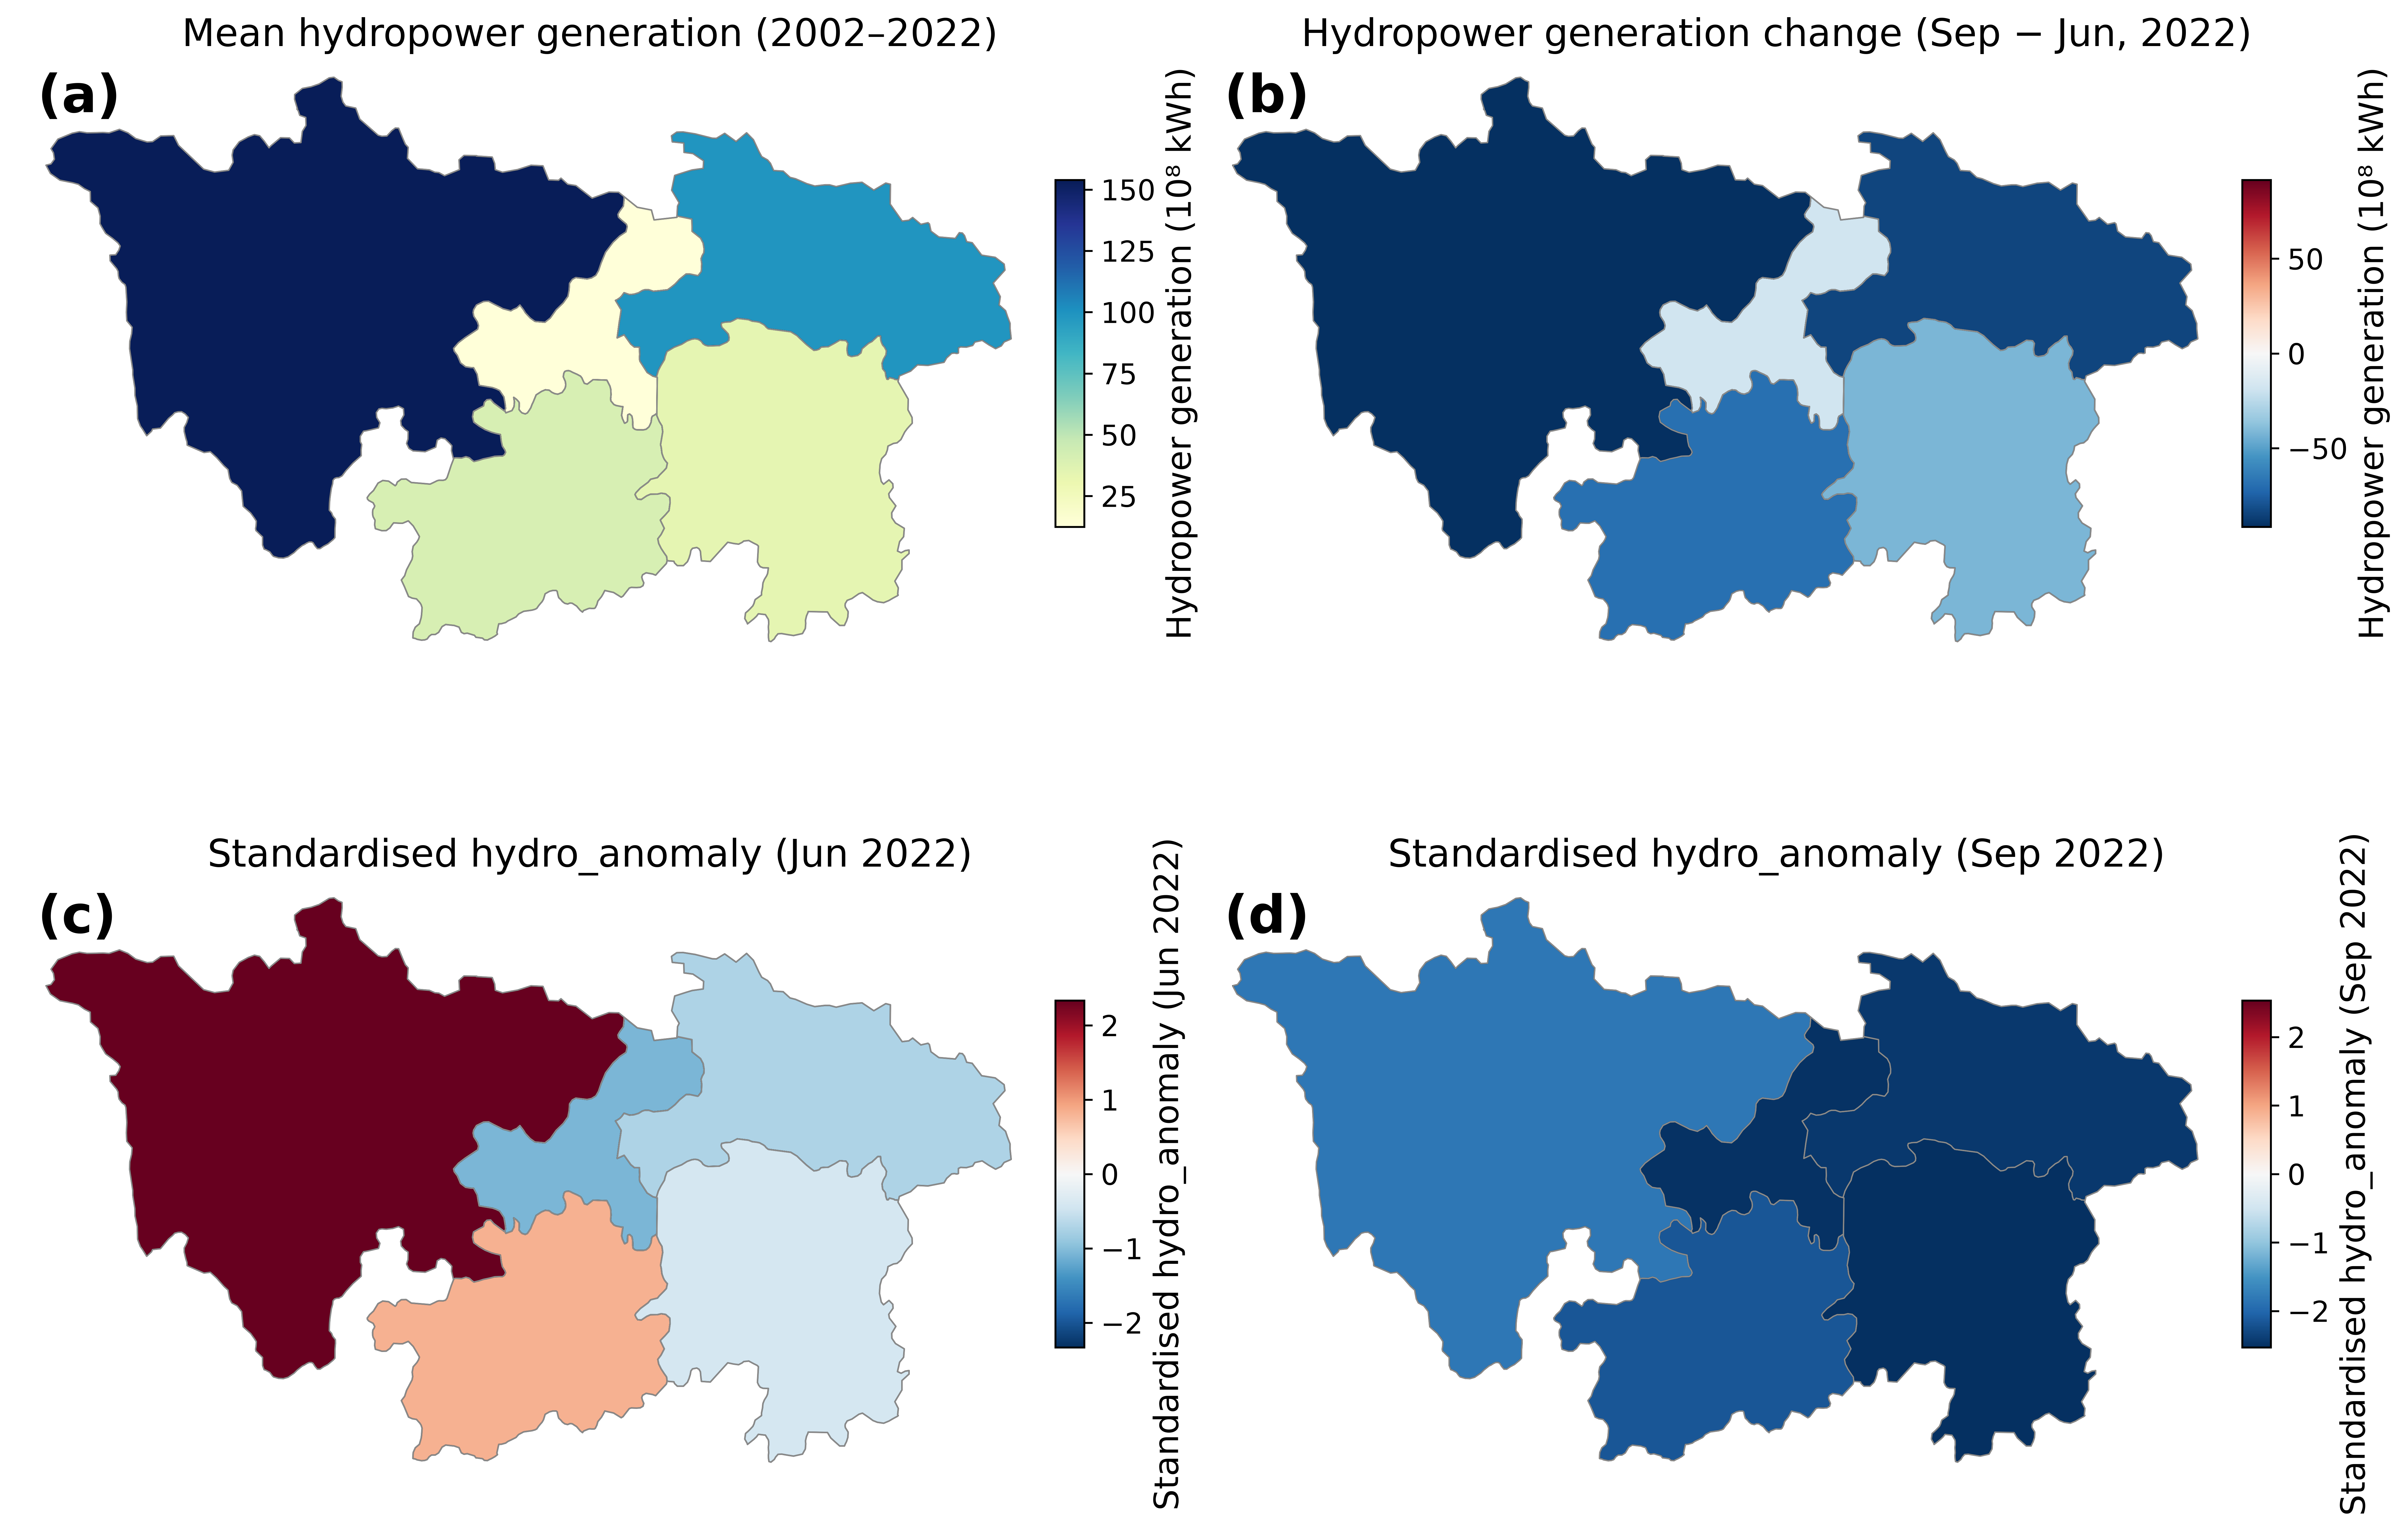


Saved figure -> /home/users/weijia_6/Yangtze_code/gen_result/china_2x2_hydro_and_anomalyStd_2022.png

Computed province values:
  province_key province_cn  mean_hydro_2002_2022  hydro_2022_06  \
0      sichuan          四川            153.875909          426.4   
1    chongqing          重庆             12.392273           28.0   
2        hubei          湖北             99.009545          145.6   
3        hunan          湖南             33.996364           62.2   
4      guizhou          贵州             40.070455           98.0   

   hydro_2022_09  hydro_diff_2022_09_minus_06  anom_2022_06  anom_2022_09  
0          333.0                        -93.4      2.651477     -1.828918  
1            9.7                        -18.3     -1.059296     -2.495273  
2           61.6                        -84.0     -0.727740     -2.451367  
3           20.7                        -41.5     -0.412488     -2.543000  
4           28.9                        -69.1      0.820753     -2.161249  


In [5]:
import os
import glob
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ------------------------------------------------------------
# Font settings
# ------------------------------------------------------------
plt.rcParams["font.family"] = "DejaVu Sans"

# =========================
# User settings
# =========================
DATA_DIR = "/home/users/weijia_6/Yangtze_code/gen_data/hydropower_anomaly"
FILE_GLOB = "*_hydro_anomaly_and_std_in_reg.csv"

PROVINCE_BOUNDARY_SHP = "/home/users/weijia_6/Yangtze_code/geoBoundaries-CHN-ADM1-all/geoBoundaries-CHN-ADM1.shp"
YANGTZE_SHP = "/home/users/weijia_6/Yangtze_code/liuyu/liuyu.shp"

PROVINCES_TARGET = [
    "sichuan",
    "chongqing",
    "hubei",
    "hunan",
    "guizhou",
]

PINYIN_TO_CN = {
    "sichuan": "四川",
    "chongqing": "重庆",
    "hubei": "湖北",
    "hunan": "湖南",
    "guizhou": "贵州",
}
CN_TO_PINYIN = {v: k for k, v in PINYIN_TO_CN.items()}

LEFT_YEAR_START, LEFT_YEAR_END = 2002, 2022
YEAR_FOCUS = 2022
MONTH_SINGLE_1 = 6   # Jun
MONTH_SINGLE_2 = 9   # Sep

ANOM_CLIP_PCTL = 95

FIG_DPI = 600
TITLE_FONTSIZE = 16
CBAR_TICK_FONTSIZE = 12
CBAR_LABEL_FONTSIZE = 14

OUT_FIG = "/home/users/weijia_6/Yangtze_code/gen_result/china_2x2_hydro_and_anomalyStd_2022.png"

PANEL_LABELS = {(0, 0): "(a)", (0, 1): "(b)", (1, 0): "(c)", (1, 1): "(d)"}
PANEL_LABEL_FONTSIZE = 22
PANEL_LABEL_X = 0.02
PANEL_LABEL_Y = 0.98

# More balanced spacing
HSPACE = 0.14
WSPACE = 0.16


# =========================
# Helpers
# =========================
def infer_province_from_filename(fp: str) -> str:
    base = os.path.basename(fp).lower()
    m = re.match(r"(.+?)_hydro_anomaly_and_std(?:_capacity)?_in_reg\.csv$", base)
    if m:
        return m.group(1).strip()
    return base.split("_")[0].strip()


def pick_anom_std_column(df: pd.DataFrame) -> str:
    if "anomaly_std" in df.columns:
        return "anomaly_std"
    if "std_anomaly" in df.columns:
        return "std_anomaly"
    raise ValueError("Cannot find anomaly_std or std_anomaly column in the CSV.")


def load_one_province_csv(fp: str) -> tuple[pd.DataFrame, str]:
    df = pd.read_csv(fp)

    if ("year" not in df.columns) or ("month" not in df.columns):
        if "date" in df.columns:
            dt = pd.to_datetime(df["date"], errors="coerce")
        elif "time" in df.columns:
            dt = pd.to_datetime(df["time"], errors="coerce")
        else:
            raise ValueError(f"Cannot find year/month or date/time in: {fp}")
        df["year"] = dt.dt.year
        df["month"] = dt.dt.month

    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["month"] = pd.to_numeric(df["month"], errors="coerce")

    if "hydro" not in df.columns:
        raise ValueError(f"Missing column 'hydro' in: {fp}")
    df["hydro"] = pd.to_numeric(df["hydro"], errors="coerce")

    anom_std_col = pick_anom_std_column(df)
    df[anom_std_col] = pd.to_numeric(df[anom_std_col], errors="coerce")

    return df, anom_std_col


def compute_mean_for_months(df: pd.DataFrame, col: str, year: int, months: list[int]) -> float:
    d = df[(df["year"] == year) & (df["month"].isin(months))]
    return float(d[col].dropna().mean()) if len(d) else np.nan


def guess_name_column(gdf: gpd.GeoDataFrame) -> str:
    candidates = [c for c in gdf.columns if c.lower() not in ("geometry",)]
    obj_cols = [
        c for c in candidates
        if pd.api.types.is_object_dtype(gdf[c]) or pd.api.types.is_string_dtype(gdf[c])
    ]
    if not obj_cols:
        raise ValueError("Cannot find any string/object column for province names in province boundary shp.")

    def has_chinese(s: str) -> bool:
        return any("\u4e00" <= ch <= "\u9fff" for ch in str(s))

    best_col, best_score = None, -1
    for c in obj_cols:
        vals = gdf[c].dropna().astype(str)
        if len(vals) == 0:
            continue
        uniq = vals.nunique()
        sample = vals.sample(min(80, len(vals)), random_state=0)
        chinese_ratio = np.mean([has_chinese(v) for v in sample])
        score = uniq + 50.0 * chinese_ratio
        if score > best_score:
            best_score, best_col = score, c
    return best_col if best_col is not None else obj_cols[0]


def canonical_province_key(x) -> str:
    if x is None:
        return ""
    s = str(x).strip().lower()

    chinese_map = {
        "四川": "sichuan",
        "重庆": "chongqing",
        "湖北": "hubei",
        "湖南": "hunan",
        "贵州": "guizhou",
    }
    for cn, key in chinese_map.items():
        if cn in s:
            return key

    s = re.sub(r"[\s\-_().,]+", "", s)
    s = s.replace("province", "")
    s = s.replace("municipality", "")
    s = s.replace("city", "")
    s = s.replace("autonomousregion", "")
    s = s.replace("autonomous", "")
    s = s.replace("region", "")

    for eng in ["sichuan", "chongqing", "hubei", "hunan", "guizhou"]:
        if eng in s:
            return eng

    return ""


def robust_two_slope_norm(values: np.ndarray, clip_pctl: float) -> TwoSlopeNorm:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        vmax = 1.0
    else:
        abs_vals = np.abs(values)
        vmax = float(np.percentile(abs_vals, clip_pctl))
        if (not np.isfinite(vmax)) or vmax == 0:
            vmax = float(np.nanmax(abs_vals)) if np.nanmax(abs_vals) > 0 else 1.0
    return TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)


def add_inset_colorbar(fig, ax, sm, label: str):
    cax = inset_axes(
        ax,
        width="2.8%",
        height="58%",
        loc="lower left",
        bbox_to_anchor=(1.015, 0.22, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )
    cbar = fig.colorbar(sm, cax=cax, orientation="vertical")
    cbar.ax.tick_params(labelsize=CBAR_TICK_FONTSIZE)
    cbar.set_label(label, fontsize=CBAR_LABEL_FONTSIZE)
    return cbar


def add_panel_label(ax, label: str):
    ax.text(
        PANEL_LABEL_X,
        PANEL_LABEL_Y,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=PANEL_LABEL_FONTSIZE,
        fontweight="bold",
        color="black",
    )


def plot_map_panel(
    fig,
    ax,
    geometry_data,
    colour_column,
    cmap,
    norm,
    title,
    panel_label,
    cbar_label,
):
    geometry_data.boundary.plot(ax=ax, linewidth=0.5, color="0.55")

    g = geometry_data.loc[geometry_data[colour_column].notna()].copy()

    if len(g) == 0:
        ax.text(
            0.5,
            0.5,
            "No matched data",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=14,
            color="red",
            fontweight="bold",
        )
    else:
        g.plot(
            ax=ax,
            column=colour_column,
            cmap=cmap,
            linewidth=0.6,
            edgecolor="0.25",
            norm=norm,
            legend=False,
        )

        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        add_inset_colorbar(fig, ax, sm, cbar_label)

    ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=6, x = 0.56)
    ax.axis("off")
    add_panel_label(ax, panel_label)


# =========================
# Main
# =========================
def main():
    csv_files = glob.glob(os.path.join(DATA_DIR, FILE_GLOB))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found: {os.path.join(DATA_DIR, FILE_GLOB)}")

    csv_by_prov = {infer_province_from_filename(fp): fp for fp in csv_files}

    records = []
    for prov in PROVINCES_TARGET:
        fp = csv_by_prov.get(prov)
        if fp is None:
            print(f"[WARN] Missing CSV for province: {prov}")
            records.append({
                "province_key": prov,
                "province_cn": PINYIN_TO_CN.get(prov, ""),
                "mean_hydro_2002_2022": np.nan,
                "hydro_2022_06": np.nan,
                "hydro_2022_09": np.nan,
                "hydro_diff_2022_09_minus_06": np.nan,
                "anom_2022_06": np.nan,
                "anom_2022_09": np.nan,
            })
            continue

        df, anom_std_col = load_one_province_csv(fp)

        d1 = df[(df["year"] >= LEFT_YEAR_START) & (df["year"] <= LEFT_YEAR_END)]
        mean_hydro = float(d1["hydro"].dropna().mean()) if len(d1) else np.nan

        hydro_06 = compute_mean_for_months(df, "hydro", YEAR_FOCUS, [MONTH_SINGLE_1])
        hydro_09 = compute_mean_for_months(df, "hydro", YEAR_FOCUS, [MONTH_SINGLE_2])
        hydro_diff = (hydro_09 - hydro_06) if (np.isfinite(hydro_06) and np.isfinite(hydro_09)) else np.nan

        anom_06 = compute_mean_for_months(df, anom_std_col, YEAR_FOCUS, [MONTH_SINGLE_1])
        anom_09 = compute_mean_for_months(df, anom_std_col, YEAR_FOCUS, [MONTH_SINGLE_2])

        print(
            f"[DEBUG] {prov:10s} | hydro Jun={hydro_06: .4f} | hydro Sep={hydro_09: .4f} | diff(Sep-Jun)={hydro_diff: .4f} "
            f"| {anom_std_col} Jun={anom_06: .4f} | Sep={anom_09: .4f}"
        )

        records.append({
            "province_key": prov,
            "province_cn": PINYIN_TO_CN.get(prov, ""),
            "mean_hydro_2002_2022": mean_hydro,
            "hydro_2022_06": hydro_06,
            "hydro_2022_09": hydro_09,
            "hydro_diff_2022_09_minus_06": hydro_diff,
            "anom_2022_06": anom_06,
            "anom_2022_09": anom_09,
        })

    stats_df = pd.DataFrame(records)

    provinces_gdf = gpd.read_file(PROVINCE_BOUNDARY_SHP)
    if provinces_gdf.crs is None:
        raise ValueError("Province boundary shapefile CRS is None. Please check 省界_Project.shp.")

    name_col = guess_name_column(provinces_gdf)
    provinces_gdf["province_key"] = provinces_gdf[name_col].apply(canonical_province_key)

    print("\n[SHAPEFILE NAME CHECK]")
    print("  guessed name column:", name_col)
    print("  unique canonical keys:", sorted(set(provinces_gdf["province_key"].dropna().astype(str)) - {""}))

    provinces_gdf = provinces_gdf.loc[provinces_gdf["province_key"].isin(PROVINCES_TARGET)].copy()

    if provinces_gdf.empty:
        raise ValueError(
            "No provinces matched after canonicalization. "
            "Please inspect the shapefile name column and adjust canonical_province_key()."
        )

    provinces_gdf = provinces_gdf.dissolve(by="province_key", as_index=False)

    yangtze_gdf = gpd.read_file(YANGTZE_SHP)
    if yangtze_gdf.crs != provinces_gdf.crs:
        yangtze_gdf = yangtze_gdf.to_crs(provinces_gdf.crs)

    provinces_gdf = provinces_gdf.merge(stats_df, on="province_key", how="left")

    print("\n[MERGE CHECK]")
    for col in [
        "mean_hydro_2002_2022",
        "hydro_diff_2022_09_minus_06",
        "anom_2022_06",
        "anom_2022_09",
    ]:
        n_valid = int(provinces_gdf[col].notna().sum())
        print(f"  {col}: {n_valid}/{len(provinces_gdf)} provinces matched")

    minx, miny, maxx, maxy = provinces_gdf.total_bounds
    pad_x = (maxx - minx) * 0.03
    pad_y = (maxy - miny) * 0.03
    xlim = (minx - pad_x, maxx + pad_x)
    ylim = (miny - pad_y, maxy + pad_y)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 10.2),
        dpi=FIG_DPI,
    )

    # TL: mean hydro
    ax = axes[0, 0]
    col = "mean_hydro_2002_2022"
    g = provinces_gdf.loc[provinces_gdf[col].notna()].copy()
    if len(g):
        vmin, vmax = float(g[col].min()), float(g[col].max())
        norm = Normalize(vmin=vmin, vmax=vmax)
        plot_map_panel(
            fig=fig,
            ax=ax,
            geometry_data=provinces_gdf,
            colour_column=col,
            cmap="YlGnBu",
            norm=norm,
            title="Mean hydropower generation (2002–2022)",
            panel_label=PANEL_LABELS[(0, 0)],
            cbar_label="Hydropower generation (10⁸ kWh)",
        )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    # TR: Sep - Jun hydro change
    ax = axes[0, 1]
    col = "hydro_diff_2022_09_minus_06"
    g = provinces_gdf.loc[provinces_gdf[col].notna()].copy()
    if len(g):
        norm = robust_two_slope_norm(g[col].values, ANOM_CLIP_PCTL)
        plot_map_panel(
            fig=fig,
            ax=ax,
            geometry_data=provinces_gdf,
            colour_column=col,
            cmap="RdBu_r",
            norm=norm,
            title="Hydropower generation change (Sep − Jun, 2022)",
            panel_label=PANEL_LABELS[(0, 1)],
            cbar_label="Hydropower generation (10⁸ kWh)",
        )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    # BL: Jun 2022 standardised anomaly
    ax = axes[1, 0]
    col = "anom_2022_06"
    g = provinces_gdf.loc[provinces_gdf[col].notna()].copy()
    if len(g):
        norm = robust_two_slope_norm(g[col].values, ANOM_CLIP_PCTL)
        plot_map_panel(
            fig=fig,
            ax=ax,
            geometry_data=provinces_gdf,
            colour_column=col,
            cmap="RdBu_r",
            norm=norm,
            title="Standardised hydro_anomaly (Jun 2022)",
            panel_label=PANEL_LABELS[(1, 0)],
            cbar_label="Standardised hydro_anomaly (Jun 2022)",
        )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    # BR: Sep 2022 standardised anomaly
    ax = axes[1, 1]
    col = "anom_2022_09"
    g = provinces_gdf.loc[provinces_gdf[col].notna()].copy()
    if len(g):
        norm = robust_two_slope_norm(g[col].values, ANOM_CLIP_PCTL)
        plot_map_panel(
            fig=fig,
            ax=ax,
            geometry_data=provinces_gdf,
            colour_column=col,
            cmap="RdBu_r",
            norm=norm,
            title="Standardised hydro_anomaly (Sep 2022)",
            panel_label=PANEL_LABELS[(1, 1)],
            cbar_label="Standardised hydro_anomaly (Sep 2022)",
        )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    fig.subplots_adjust(
        left=0.04,
        right=0.96,
        bottom=0.05,
        top=0.93,
        wspace=WSPACE,
        hspace=HSPACE,
    )

    fig.savefig(OUT_FIG, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

    print(f"\nSaved figure -> {OUT_FIG}")
    print("\nComputed province values:")
    print(stats_df)


if __name__ == "__main__":
    main()